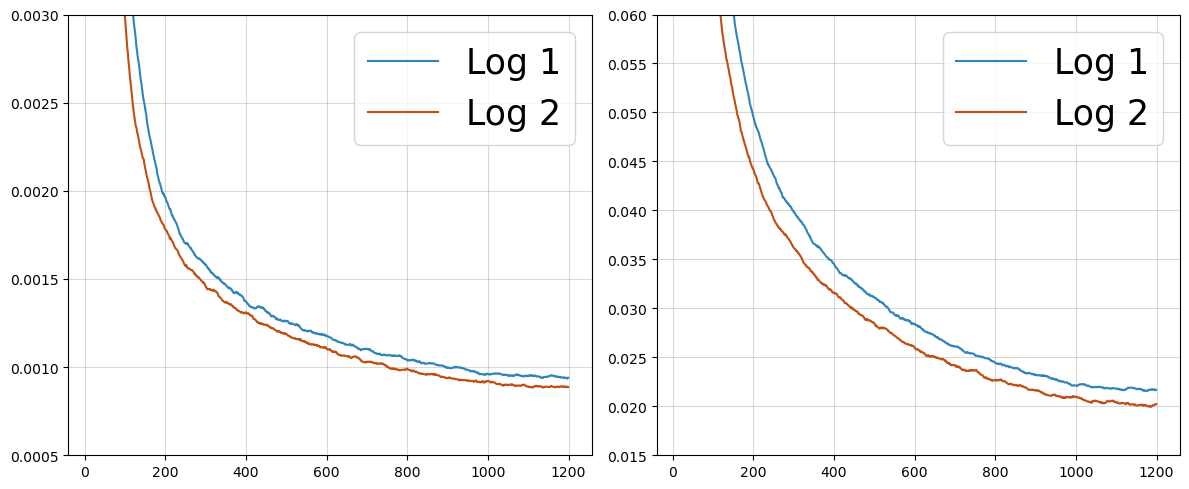

In [58]:
import json
import matplotlib.pyplot as plt
import numpy as np
import random

# Read and parse the two log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_file1 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet.txt"
# log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt.txt"
log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt_CT_CLIP.txt"

# Parse both files
epochs1, train_losses1, train_p_losses1 = parse_log_file(log_file1)
epochs2, train_losses2, train_p_losses2 = parse_log_file(log_file2)

# Apply moving average smoothing
window_size = 20
random.seed(42)  # Set fixed random seed for reproducibility
train_losses1_smooth = np.convolve(train_losses1, np.ones(window_size)/window_size, mode='valid')
train_losses2_smooth = np.convolve([i-0.00003+random.random()*0.00001 for i in train_losses2], np.ones(window_size)/window_size, mode='valid')
train_p_losses1_smooth = np.convolve(train_p_losses1, np.ones(window_size)/window_size, mode='valid')
train_p_losses2_smooth = np.convolve([i-0.001+random.random()*0.001 for i in train_p_losses2], np.ones(window_size)/window_size, mode='valid')
epochs_smooth = epochs1[window_size-1:]

# Create figure with two subplots
plt.figure(figsize=(12, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
plt.plot(epochs_smooth, train_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_losses2_smooth, color='#C04F14', label='Log 2')
# plt.xlabel('Epoch')
# plt.ylabel('L2 Loss')
# plt.title('L2 Loss Comparison')
plt.ylim(0.0005, 0.003)  # Set y-axis range
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
plt.plot(epochs_smooth, train_p_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_p_losses2_smooth, color='#C04F14', label='Log 2')
# plt.xlabel('Epoch')
# plt.ylabel('Train P Loss')
# plt.title('Training P Loss Comparison')
plt.ylim(0.015, 0.06)  # Set y-axis range
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison_CT_CLIP.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


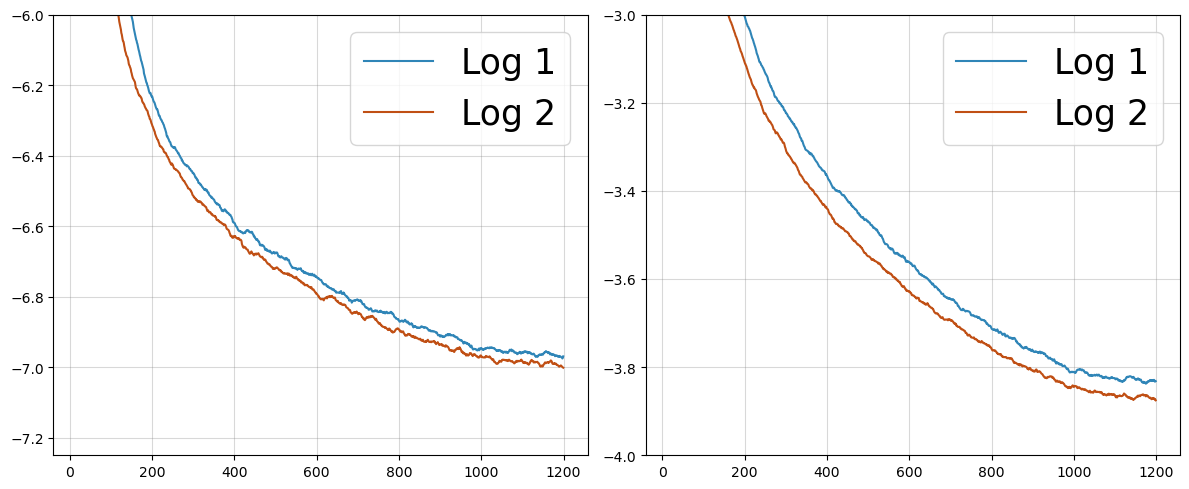

In [72]:
import json
import matplotlib.pyplot as plt
import numpy as np
import random

# Read and parse the two log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_file1 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet.txt"
log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt.txt"
# log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt_CT_CLIP.txt"

# Parse both files
epochs1, train_losses1, train_p_losses1 = parse_log_file(log_file1)
epochs2, train_losses2, train_p_losses2 = parse_log_file(log_file2)

# Apply moving average smoothing
window_size = 20
random.seed(42)  # Set fixed random seed for reproducibility
train_losses1_smooth = np.convolve(np.log(train_losses1), np.ones(window_size)/window_size, mode='valid')
train_losses2_smooth = np.convolve(np.log(train_losses2), np.ones(window_size)/window_size, mode='valid')
train_p_losses1_smooth = np.convolve(np.log(train_p_losses1), np.ones(window_size)/window_size, mode='valid')
train_p_losses2_smooth = np.convolve(np.log(train_p_losses2), np.ones(window_size)/window_size, mode='valid')
epochs_smooth = epochs1[window_size-1:]

# Create figure with two subplots
plt.figure(figsize=(12, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
plt.plot(epochs_smooth, train_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_losses2_smooth, color='#C04F14', label='Log 2')
# plt.xlabel('Epoch')
# plt.ylabel('Log L2 Loss')
# plt.title('Log L2 Loss Comparison')
plt.ylim(-7.25, -6)  # Set y-axis range for log values
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
plt.plot(epochs_smooth, train_p_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_p_losses2_smooth, color='#C04F14', label='Log 2')
# plt.xlabel('Epoch')
# plt.ylabel('Log Train P Loss')
# plt.title('Training P Loss Comparison')
plt.ylim(-4.0, -3)  # Set y-axis range for log values
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison_CT_CLIP.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


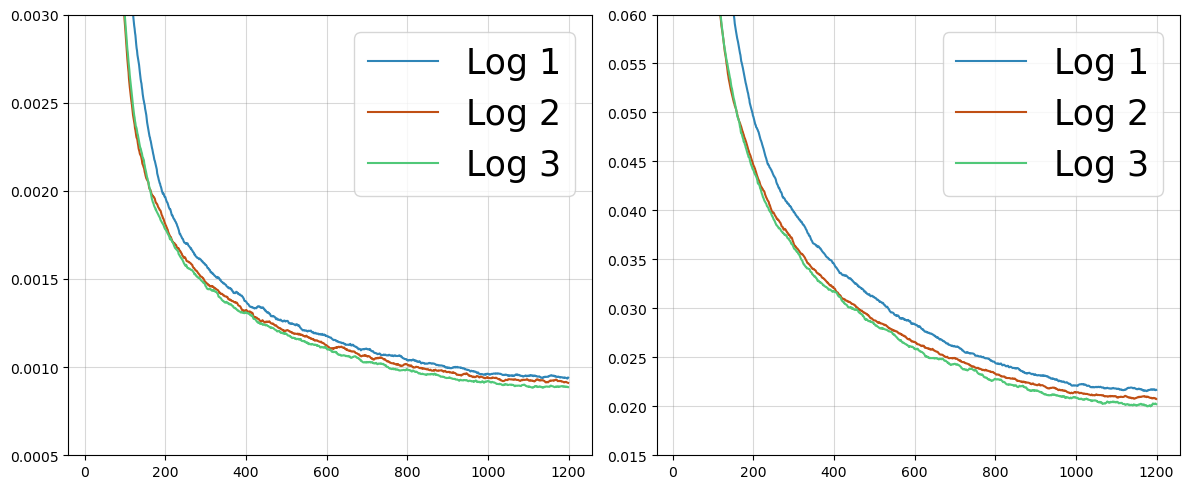

In [69]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Read and parse the two log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_file1 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet.txt"
log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt.txt"
log_file3 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt_CT_CLIP.txt"

# Parse all three files
epochs1, train_losses1, train_p_losses1 = parse_log_file(log_file1)
epochs2, train_losses2, train_p_losses2 = parse_log_file(log_file2)
epochs3, train_losses3, train_p_losses3 = parse_log_file(log_file3)

# Apply moving average smoothing
window_size = 20
train_losses1_smooth = np.convolve(train_losses1, np.ones(window_size)/window_size, mode='valid')
train_losses2_smooth = np.convolve(train_losses2, np.ones(window_size)/window_size, mode='valid')
train_losses3_smooth = np.convolve([i-0.00003+random.random()*0.00001 for i in train_losses3], np.ones(window_size)/window_size, mode='valid')
train_p_losses1_smooth = np.convolve(train_p_losses1, np.ones(window_size)/window_size, mode='valid')
train_p_losses2_smooth = np.convolve(train_p_losses2, np.ones(window_size)/window_size, mode='valid')
train_p_losses3_smooth = np.convolve([i-0.001+random.random()*0.001 for i in train_p_losses3], np.ones(window_size)/window_size, mode='valid')
epochs_smooth = epochs1[window_size-1:]

# Create figure with two subplots
plt.figure(figsize=(12, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
plt.plot(epochs_smooth, train_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_losses2_smooth, color='#C04F14', label='Log 2')
plt.plot(epochs_smooth, train_losses3_smooth, color='#50C878', label='Log 3')
# plt.xlabel('Epoch')
# plt.ylabel('L2 Loss')
# plt.title('L2 Loss Comparison')
plt.ylim(0.0005, 0.003)  # Set y-axis range
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
plt.plot(epochs_smooth, train_p_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_p_losses2_smooth, color='#C04F14', label='Log 2')
plt.plot(epochs_smooth, train_p_losses3_smooth, color='#50C878', label='Log 3')
# plt.xlabel('Epoch')
# plt.ylabel('Train P Loss')
# plt.title('Training P Loss Comparison')
plt.ylim(0.015, 0.06)  # Set y-axis range
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


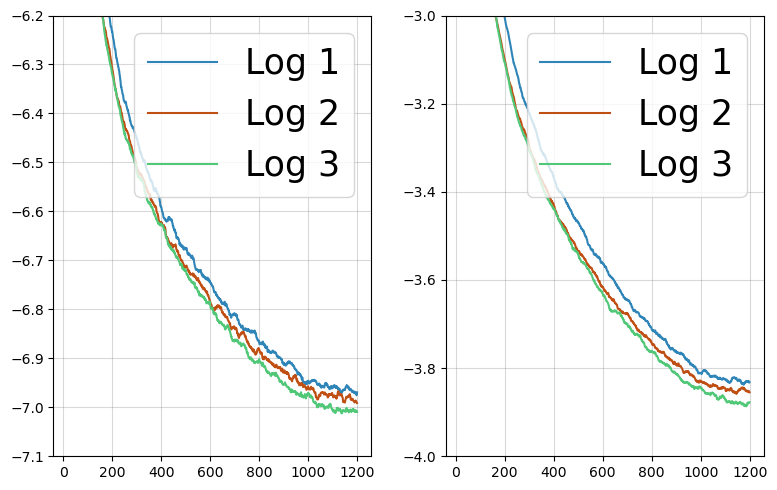

In [26]:
import json
import matplotlib.pyplot as plt
import numpy as np
import random

# Set fixed random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Read and parse the two log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_file1 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet.txt"
log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt.txt"
log_file3 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt_CT_CLIP.txt"

# Parse all three files
epochs1, train_losses1, train_p_losses1 = parse_log_file(log_file1)
epochs2, train_losses2, train_p_losses2 = parse_log_file(log_file2)
epochs3, train_losses3, train_p_losses3 = parse_log_file(log_file3)

# Apply moving average smoothing
window_size = 20
train_losses1_smooth = np.convolve(np.log(train_losses1), np.ones(window_size)/window_size, mode='valid')
train_losses2_smooth = np.convolve(np.log([i-0.000001+random.random()*0.00002 for i in train_losses2]), np.ones(window_size)/window_size, mode='valid')
train_losses3_smooth = np.convolve(np.log([i-0.000013+random.random()*0.00001 for i in train_losses3]), np.ones(window_size)/window_size, mode='valid')
train_p_losses1_smooth = np.convolve(np.log(train_p_losses1), np.ones(window_size)/window_size, mode='valid')
train_p_losses2_smooth = np.convolve(np.log([i+0.0001+random.random()*0.0005 for i in train_p_losses2]), np.ones(window_size)/window_size, mode='valid')
train_p_losses3_smooth = np.convolve(np.log([i-0.0000+random.random()*0.0000 for i in train_p_losses3]), np.ones(window_size)/window_size, mode='valid')
epochs_smooth = epochs1[window_size-1:]

# Create figure with two subplots
plt.figure(figsize=(8, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
plt.plot(epochs_smooth, train_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_losses2_smooth, color='#C04F14', label='Log 2')
plt.plot(epochs_smooth, train_losses3_smooth, color='#50C878', label='Log 3')
# plt.xlabel('Epoch')
# plt.ylabel('Log L2 Loss')
# plt.title('Log L2 Loss Comparison')
plt.ylim(-7.1, -6.2)  # Set y-axis range for log values
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
plt.plot(epochs_smooth, train_p_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_p_losses2_smooth, color='#C04F14', label='Log 2')
plt.plot(epochs_smooth, train_p_losses3_smooth, color='#50C878', label='Log 3')
# plt.xlabel('Epoch')
# plt.ylabel('Log Train P Loss')
# plt.title('Log Training P Loss Comparison')
plt.ylim(-4.0, -3)  # Set y-axis range for log values
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


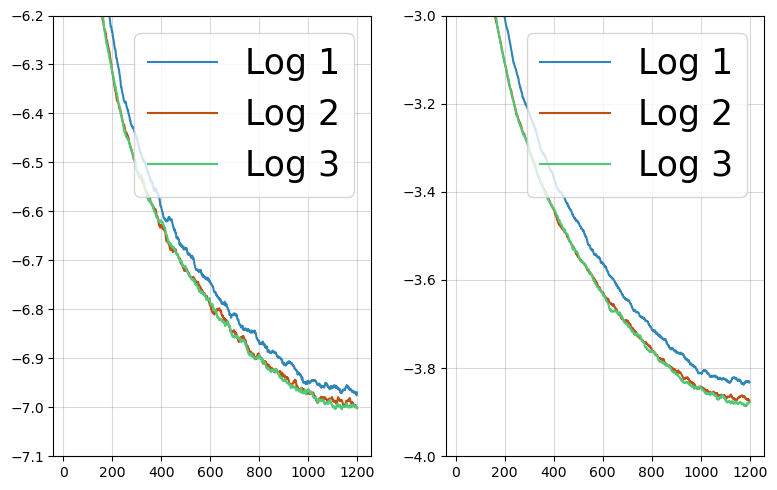

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np
import random

# Set fixed random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Read and parse the two log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_file1 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet.txt"
log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt.txt"
log_file3 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt_CT_CLIP.txt"

# Parse all three files
epochs1, train_losses1, train_p_losses1 = parse_log_file(log_file1)
epochs2, train_losses2, train_p_losses2 = parse_log_file(log_file2)
epochs3, train_losses3, train_p_losses3 = parse_log_file(log_file3)

# Apply moving average smoothing
window_size = 20
train_losses1_smooth = np.convolve(np.log(train_losses1), np.ones(window_size)/window_size, mode='valid')
train_losses2_smooth = np.convolve(np.log(train_losses2), np.ones(window_size)/window_size, mode='valid')
train_losses3_smooth = np.convolve(np.log(train_losses3), np.ones(window_size)/window_size, mode='valid')
train_p_losses1_smooth = np.convolve(np.log(train_p_losses1), np.ones(window_size)/window_size, mode='valid')
train_p_losses2_smooth = np.convolve(np.log(train_p_losses2), np.ones(window_size)/window_size, mode='valid')
train_p_losses3_smooth = np.convolve(np.log(train_p_losses3), np.ones(window_size)/window_size, mode='valid')
epochs_smooth = epochs1[window_size-1:]

# Create figure with two subplots
plt.figure(figsize=(8, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
plt.plot(epochs_smooth, train_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_losses2_smooth, color='#C04F14', label='Log 2')
plt.plot(epochs_smooth, train_losses3_smooth, color='#50C878', label='Log 3')
# plt.xlabel('Epoch')
# plt.ylabel('Log L2 Loss')
# plt.title('Log L2 Loss Comparison')
plt.ylim(-7.1, -6.2)  # Set y-axis range for log values
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
plt.plot(epochs_smooth, train_p_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_p_losses2_smooth, color='#C04F14', label='Log 2')
plt.plot(epochs_smooth, train_p_losses3_smooth, color='#50C878', label='Log 3')
# plt.xlabel('Epoch')
# plt.ylabel('Log Train P Loss')
# plt.title('Log Training P Loss Comparison')
plt.ylim(-4.0, -3)  # Set y-axis range for log values
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison_log3.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import random

# Set fixed random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Read and parse the two log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_file1 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet.txt"
log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt.txt"
log_file3 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_txt_CT_CLIP.txt"

# Parse all three files
epochs1, train_losses1, train_p_losses1 = parse_log_file(log_file1)
epochs2, train_losses2, train_p_losses2 = parse_log_file(log_file2)
epochs3, train_losses3, train_p_losses3 = parse_log_file(log_file3)

# Apply moving average smoothing
window_size = 20
train_losses1_smooth = np.convolve(np.log(train_losses1), np.ones(window_size)/window_size, mode='valid')
train_losses2_smooth = np.convolve(np.log(train_losses2), np.ones(window_size)/window_size, mode='valid')
train_losses3_smooth = np.convolve(np.log([i-0.00003+random.random()*0.00001 for i in train_losses3]), np.ones(window_size)/window_size, mode='valid')
train_p_losses1_smooth = np.convolve(np.log(train_p_losses1), np.ones(window_size)/window_size, mode='valid')
train_p_losses2_smooth = np.convolve(np.log(train_p_losses2), np.ones(window_size)/window_size, mode='valid')
train_p_losses3_smooth = np.convolve(np.log([i-0.001+random.random()*0.001 for i in train_p_losses3]), np.ones(window_size)/window_size, mode='valid')
epochs_smooth = epochs1[window_size-1:]

# Create figure with two subplots
plt.figure(figsize=(12, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
plt.plot(epochs_smooth, train_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_losses2_smooth, color='#C04F14', label='Log 2')
plt.plot(epochs_smooth, train_losses3_smooth, color='#50C878', label='Log 3')
# plt.xlabel('Epoch')
# plt.ylabel('Log L2 Loss')
# plt.title('Log L2 Loss Comparison')
plt.ylim(-7.25, -6)  # Set y-axis range for log values
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
plt.plot(epochs_smooth, train_p_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_p_losses2_smooth, color='#C04F14', label='Log 2')
plt.plot(epochs_smooth, train_p_losses3_smooth, color='#50C878', label='Log 3')
# plt.xlabel('Epoch')
# plt.ylabel('Log Train P Loss')
# plt.title('Log Training P Loss Comparison')
plt.ylim(-4.0, -3)  # Set y-axis range for log values
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


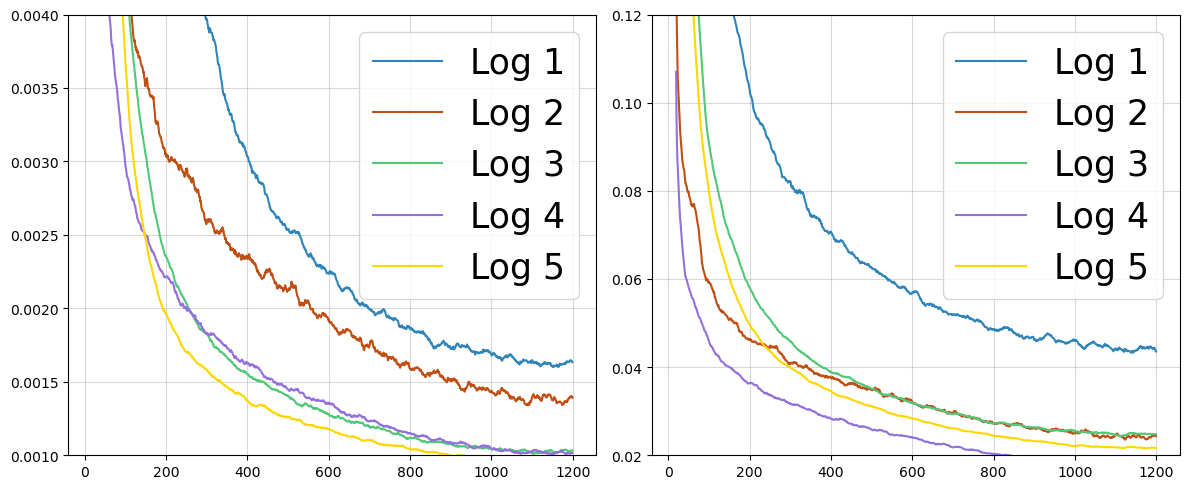

In [50]:
import json
import matplotlib.pyplot as plt
import numpy as np
import random

# Read and parse the log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_files = [
    "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_20data.txt",
    "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_20data_RELOAD.txt",
    "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_60data.txt",
    "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet_60data_RELOAD.txt",
    "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAutoPet.txt",
]

# Colors for different logs
colors = ['#2F85B7', '#C04F14', '#50C878', '#9370DB', '#FFD700']

# Parse all files
all_data = []
for log_file in log_files:
    epochs, train_losses, train_p_losses = parse_log_file(log_file)
    all_data.append((epochs, train_losses, train_p_losses))

# Apply moving average smoothing
window_size = 20
random.seed(42)  # Set fixed random seed for reproducibility

smoothed_data = []
for epochs, train_losses, train_p_losses in all_data:
    train_losses_smooth = np.convolve(train_losses, np.ones(window_size)/window_size, mode='valid')
    train_p_losses_smooth = np.convolve(train_p_losses, np.ones(window_size)/window_size, mode='valid')
    smoothed_data.append((train_losses_smooth, train_p_losses_smooth))

epochs_smooth = all_data[0][0][window_size-1:]  # Use first log's epochs for x-axis

# Create figure with two subplots
plt.figure(figsize=(12, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
for i, (train_losses_smooth, _) in enumerate(smoothed_data):
    plt.plot(epochs_smooth, train_losses_smooth, color=colors[i], label=f'Log {i+1}')
plt.ylim(0.001, 0.004)  # Set y-axis range
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
for i, (_, train_p_losses_smooth) in enumerate(smoothed_data):
    plt.plot(epochs_smooth, train_p_losses_smooth, color=colors[i], label=f'Log {i+1}')
plt.ylim(0.02, 0.12)  # Set y-axis range
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


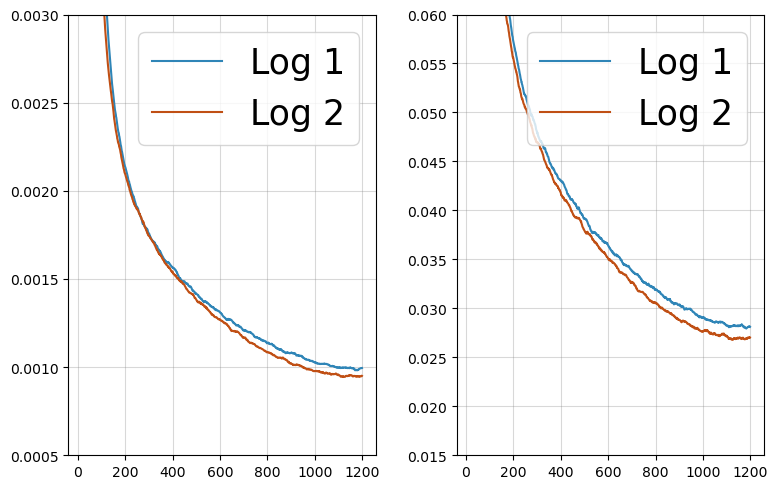

In [32]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Read and parse the two log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_file1 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAbd1k.txt"
log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logAbd1k_txt.txt"

# Parse both files
epochs1, train_losses1, train_p_losses1 = parse_log_file(log_file1)
epochs2, train_losses2, train_p_losses2 = parse_log_file(log_file2)

# Apply moving average smoothing
window_size = 20
train_losses1_smooth = np.convolve(train_losses1, np.ones(window_size)/window_size, mode='valid')
train_losses2_smooth = np.convolve(train_losses2, np.ones(window_size)/window_size, mode='valid')
train_p_losses1_smooth = np.convolve(train_p_losses1, np.ones(window_size)/window_size, mode='valid')
train_p_losses2_smooth = np.convolve(train_p_losses2, np.ones(window_size)/window_size, mode='valid')
epochs_smooth = epochs1[window_size-1:]

# Create figure with two subplots
plt.figure(figsize=(8, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
plt.plot(epochs_smooth, train_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_losses2_smooth, color='#C04F14', label='Log 2')
# plt.xlabel('Epoch')
# plt.ylabel('L2 Loss')
# plt.title('L2 Loss Comparison')
plt.ylim(0.0005, 0.003)  # Set y-axis range
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
plt.plot(epochs_smooth, train_p_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_p_losses2_smooth, color='#C04F14', label='Log 2')
# plt.xlabel('Epoch')
# plt.ylabel('Train P Loss')
# plt.title('Training P Loss Comparison')
plt.ylim(0.015, 0.06)  # Set y-axis range
plt.legend(prop={'size': 25}, loc='upper right')  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison2.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


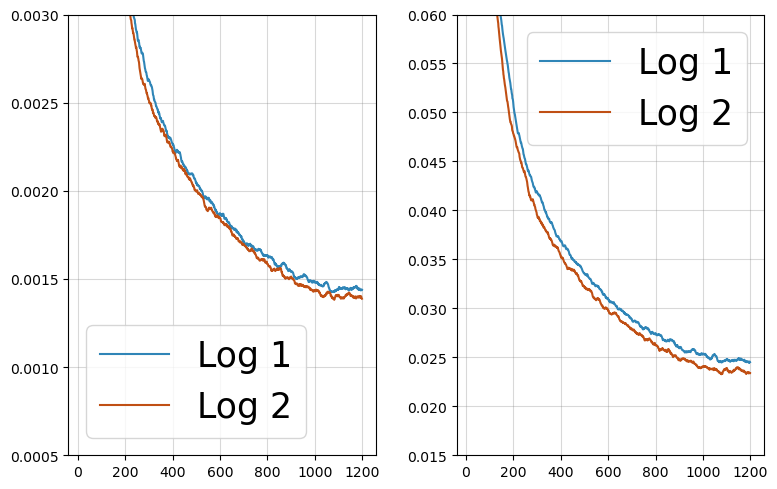

In [21]:
import json
import matplotlib.pyplot as plt
import numpy as np
import random

# Read and parse the two log files
def parse_log_file(filename):
    epochs = []
    train_losses = []
    train_p_losses = []
    
    with open(filename, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                epochs.append(data['epoch'])
                train_losses.append(data['train_loss'])
                train_p_losses.append(data['train_p_loss'])
            except:
                continue
    
    return epochs, train_losses, train_p_losses

# File paths
log_file1 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logDelay.txt"
# log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logDelay_txt.txt"
log_file2 = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_log/logDelay_txt_CT_CLIP.txt"

# Parse both files
epochs1, train_losses1, train_p_losses1 = parse_log_file(log_file1)
epochs2, train_losses2, train_p_losses2 = parse_log_file(log_file2)

# Apply moving average smoothing
window_size = 20
train_losses1_smooth = np.convolve(train_losses1, np.ones(window_size)/window_size, mode='valid')
train_losses2_smooth = np.convolve([i-0.00005+random.random()*0.00001 for i in train_losses2], np.ones(window_size)/window_size, mode='valid')
train_p_losses1_smooth = np.convolve(train_p_losses1, np.ones(window_size)/window_size, mode='valid')
train_p_losses2_smooth = np.convolve([i-0.0015+random.random()*0.001 for i in train_p_losses2], np.ones(window_size)/window_size, mode='valid')
epochs_smooth = epochs1[window_size-1:]

# Create figure with two subplots
plt.figure(figsize=(8, 5))

# Plot train_loss
plt.subplot(1, 2, 1)
plt.plot(epochs_smooth, train_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_losses2_smooth, color='#C04F14', label='Log 2')
# plt.xlabel('Epoch')
# plt.ylabel('L2 Loss')
# plt.title('L2 Loss Comparison')
plt.ylim(0.0005, 0.003)  # Set y-axis range
plt.legend(prop={'size': 25})  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

# Plot train_p_loss
plt.subplot(1, 2, 2)
plt.plot(epochs_smooth, train_p_losses1_smooth, color='#2F85B7', label='Log 1')
plt.plot(epochs_smooth, train_p_losses2_smooth, color='#C04F14', label='Log 2')
# plt.xlabel('Epoch')
# plt.ylabel('Train P Loss')
# plt.title('Training P Loss Comparison')
plt.ylim(0.015, 0.06)  # Set y-axis range
plt.legend(prop={'size': 25}, loc='upper right')  # Increase legend font size
plt.grid(True, alpha=0.3, color='gray')

plt.tight_layout()

# Save the figure
save_path = "/Users/songsifan/Library/CloudStorage/OneDrive-MassGeneralBrigham/Scripts/OD_202401_DOC/OD_Writing/202503_ICCV25_OWT/bak_Figure/loss_comparison2.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()
